In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pymc as pm
from statsmodels.tsa.stattools import adfuller
import arviz as az
import os

np.random.seed(42)


In [3]:
brent_df = pd.read_csv("/content/drive/MyDrive/raw/BrentOilPrices.csv")

In [4]:
brent_df['Date'] = pd.to_datetime(brent_df['Date'], errors='coerce', dayfirst=True)

/tmp/ipython-input-3661879019.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  brent_df['Date'] = pd.to_datetime(brent_df['Date'], errors='coerce', dayfirst=True)


In [5]:
invalid_dates = brent_df[brent_df['Date'].isna()]
if not invalid_dates.empty:
    print("Rows with invalid dates found and saved to 'invalid_dates.csv'")
    invalid_dates.to_csv('invalid_dates.csv', index=False)

In [6]:
brent_df = brent_df.dropna(subset=['Date'])

In [7]:
brent_df['Price'] = pd.to_numeric(brent_df['Price'], errors='coerce')
brent_df = brent_df.dropna(subset=['Price'])

In [8]:
brent_df = brent_df.sort_values('Date')
brent_df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [9]:
events = [
    {'Date': '14-Jul-15', 'Event': 'Iran Nuclear Deal (JCPOA) signed, easing sanctions', 'Category': 'Geopolitical'},
    {'Date': '28-Nov-16', 'Event': 'OPEC agrees to production cuts of 1.2 million bpd', 'Category': 'OPEC'},
    {'Date': '01-Jan-18', 'Event': 'US imposes sanctions on Iran, reducing oil exports', 'Category': 'Geopolitical'},
    {'Date': '01-Jan-19', 'Event': 'Qatar exits OPEC, reducing group cohesion', 'Category': 'OPEC'},
    {'Date': '07-Jan-20', 'Event': 'US-Iran tensions escalate after Soleimani assassination', 'Category': 'Geopolitical'},
    {'Date': '01-Jan-20', 'Event': 'Ecuador exits OPEC, impacting production quotas', 'Category': 'OPEC'},
    {'Date': '12-Mar-20', 'Event': 'OPEC+ fails to agree on production cuts, triggering price war', 'Category': 'OPEC'},
    {'Date': '12-Apr-20', 'Event': 'OPEC+ agrees to record production cuts of 9.7 million bpd', 'Category': 'OPEC'},
    {'Date': '24-Feb-22', 'Event': 'Russia invades Ukraine, disrupting oil supply chains', 'Category': 'Geopolitical'},
    {'Date': '01-Jun-22', 'Event': 'EU imposes partial ban on Russian oil imports', 'Category': 'Geopolitical'},
    {'Date': '05-Oct-22', 'Event': 'OPEC+ announces production cuts of 2 million bpd', 'Category': 'OPEC'},
    {'Date': '30-Sep-22', 'Event': 'Nord Stream pipeline sabotage, increasing energy concerns', 'Category': 'Geopolitical'}
]

event_df = pd.DataFrame(events)
event_df['Date'] = pd.to_datetime(event_df['Date'], format='%d-%b-%y')
event_df.to_csv('brent_oil_events.csv', index=False)

event_df.head()

,Date,Event,Category
0,2015-07-14,"Iran Nuclear Deal (JCPOA) signed, easing sanct...",Geopolitical
1,2016-11-28,OPEC agrees to production cuts of 1.2 million bpd,OPEC
2,2018-01-01,"US imposes sanctions on Iran, reducing oil exp...",Geopolitical
3,2019-01-01,"Qatar exits OPEC, reducing group cohesion",OPEC
4,2020-01-07,US-Iran tensions escalate after Soleimani assa...,Geopolitical


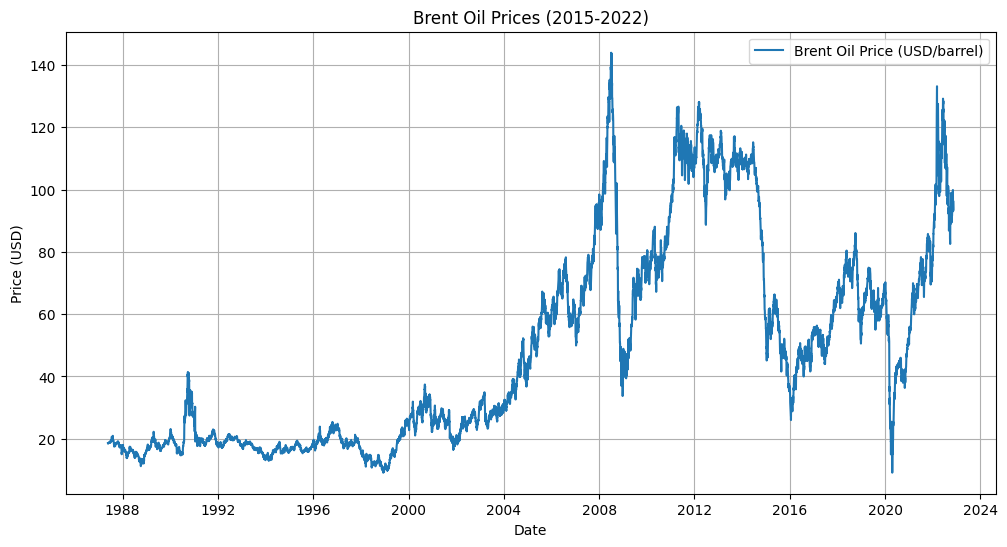

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(brent_df['Date'], brent_df['Price'], label='Brent Oil Price (USD/barrel)')
plt.title('Brent Oil Prices (2015-2022)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.savefig('brent_price_timeseries.png')
plt.show()

In [11]:
brent_df['Rolling_Mean'] = brent_df['Price'].rolling(window=30).mean()
brent_df['Rolling_Std'] = brent_df['Price'].rolling(window=30).std()

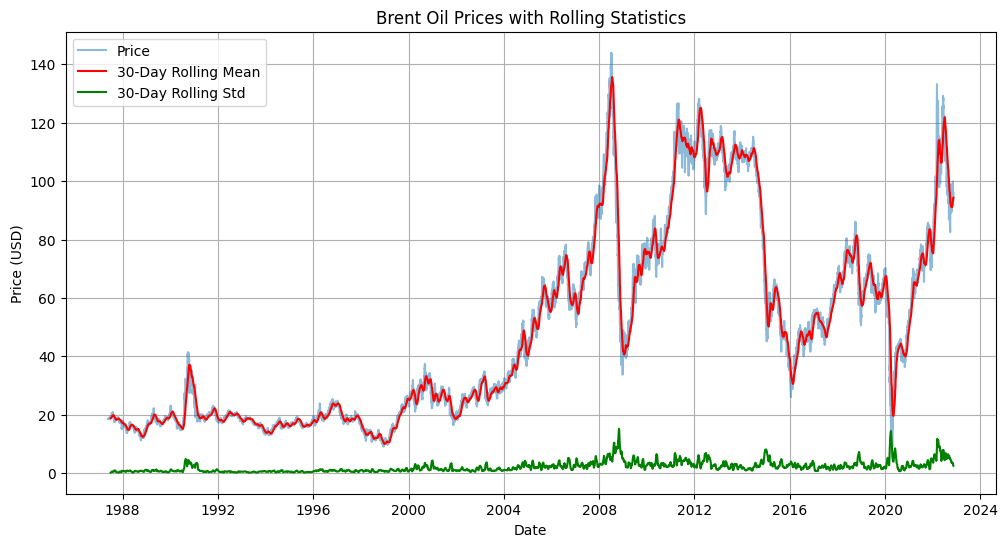

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(brent_df['Date'], brent_df['Price'], label='Price', alpha=0.5)
plt.plot(brent_df['Date'], brent_df['Rolling_Mean'], label='30-Day Rolling Mean', color='red')
plt.plot(brent_df['Date'], brent_df['Rolling_Std'], label='30-Day Rolling Std', color='green')
plt.title('Brent Oil Prices with Rolling Statistics')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.savefig('brent_price_rolling_stats.png')
plt.show()

In [13]:
adf_result = adfuller(brent_df['Price'].dropna())
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Stationarity Test: p-value < 0.05 indicates stationarity')

ADF Statistic: -1.9938560113924666
p-value: 0.2892735048934033
Stationarity Test: p-value < 0.05 indicates stationarity


In [14]:
brent_df_filtered = brent_df[(brent_df['Date'] >= '2015-01-01') & (brent_df['Date'] <= '2022-09-30')]
prices = brent_df_filtered['Price'].values
time = np.arange(len(prices))

print(f"Filtered dataset length: {len(prices)}")
brent_df_filtered.head()


Filtered dataset length: 1974


,Date,Price,Rolling_Mean,Rolling_Std
7006,2015-01-02,55.38,65.576333,7.958644
7007,2015-01-05,51.08,64.705333,8.070600
7008,2015-01-06,50.12,63.789000,8.115363
7009,2015-01-07,49.06,62.784333,8.006631
7010,2015-01-08,49.43,61.778000,7.709366


In [15]:
with pm.Model() as model:
    tau = pm.DiscreteUniform('tau', lower=0, upper=len(prices)-1)
    mu_1 = pm.Normal('mu_1', mu=50, sigma=20)
    mu_2 = pm.Normal('mu_2', mu=50, sigma=20)
    mu = pm.math.switch(tau >= time, mu_1, mu_2)
    observation = pm.Normal('obs', mu=mu, sigma=10, observed=prices)
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

Output()

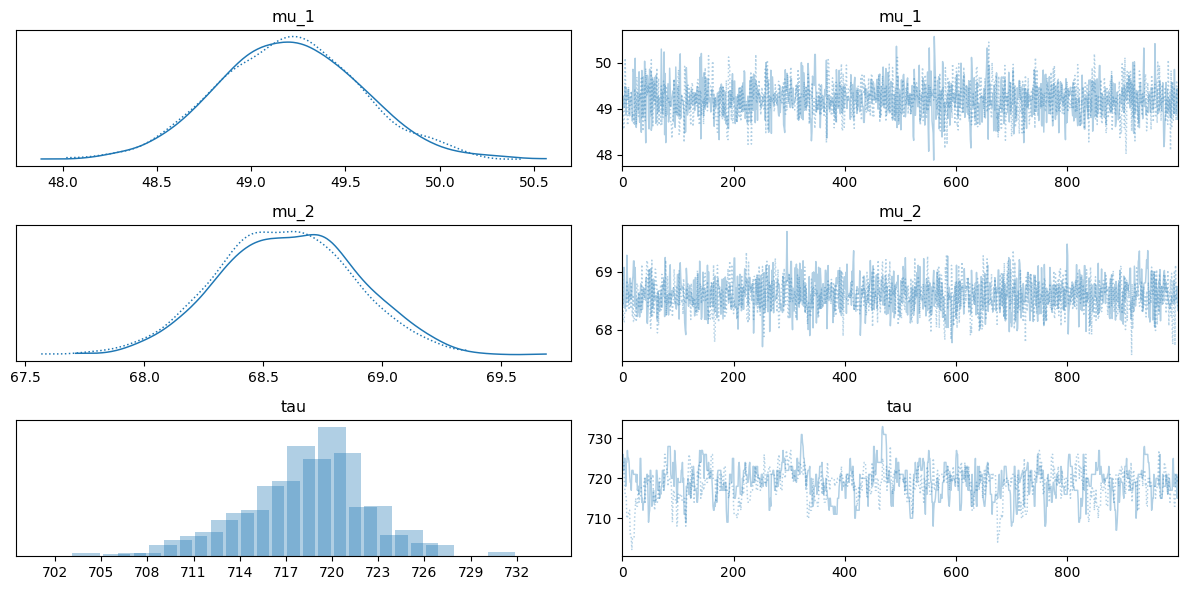

Change point model trace plot saved as 'change_point_trace.png'
Estimated change point: 2017-10-23 00:00:00


In [16]:
az.plot_trace(trace)
plt.tight_layout()
plt.savefig('change_point_trace.png')
plt.show()
print("Change point model trace plot saved as 'change_point_trace.png'")

tau_mean = int(trace.posterior['tau'].mean().values)
change_date = brent_df_filtered['Date'].iloc[tau_mean]
print(f'Estimated change point: {change_date}')


In [18]:
brent_df.to_csv('/content/drive/MyDrive/processed/processed_brent_data.csv', index=False)
print("Processed Brent data saved as '/content/drive/MyDrive/processed/processed_brent_data.csv'")


Processed Brent data saved as '/content/drive/MyDrive/processed/processed_brent_data.csv'
